Install Dependencies

In [1]:
!pip install requests beautifulsoup4 wordcloud matplotlib scikit-learn nltk numpy pandas -q

Import Libraries

In [2]:
import requests, re, random, time, math
from bs4 import BeautifulSoup
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
nltk.download('punkt'); nltk.download('stopwords'); nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

STOP_WORDS = set(stopwords.words('english'))
np.random.seed(42)
random.seed(42)
print("All imports done.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


All imports done.


Scraper

In [3]:
def scrape_page(url):
    """
    Fetches and parses a single URL.
    Returns cleaned English-only plain text.
    Removes boilerplate, scripts, styles, navigation elements.
    """
    headers = {"User-Agent": "Mozilla/5.0"}
    try:
        response = requests.get(url, headers=headers, timeout=15)
        response.raise_for_status()
    except Exception as e:
        print(f"[SKIP] Could not fetch {url}: {e}")
        return ""

    soup = BeautifulSoup(response.text, "html.parser")

    # Remove non-content tags
    for tag in soup(["script", "style", "nav", "footer", "header", "noscript", "form"]):
        tag.decompose()

    text = soup.get_text(separator=" ")

    # Remove lines that are too short (boilerplate / menu items)
    lines = [line.strip() for line in text.splitlines()]
    lines = [line for line in lines if len(line) > 20]
    text = " ".join(lines)

    # Keep only ASCII; drop Hindi/Devanagari and other scripts
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)

    # Remove excessive whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [4]:
URLS = [
    # 1. Main / About
    "https://www.iitj.ac.in/main/en/iitj",
    "https://www.iitj.ac.in/main/en/introduction",

    # 2. Academics (departments, programmes)
    "https://www.iitj.ac.in/m/Index/main-departments?lg=en",
    "https://www.iitj.ac.in/chemical-engineering/",
    "https://www.iitj.ac.in/computer-science-engineering/",
    "https://www.iitj.ac.in/electrical-engineering/",
    "https://www.iitj.ac.in/mechanical-engineering/",
    "https://www.iitj.ac.in/m/Index/main-schools?lg=en",
    "https://www.iitj.ac.in/school-of-artificial-intelligence-data-science/en/school-of-artificial-intelligence-and-data-science",
    "https://www.iitj.ac.in/school-of-design/",
    "https://www.iitj.ac.in/m/Index/main-programs?lg=en",
    "https://www.iitj.ac.in/Bachelor-of-Technology/en/Bachelor-of-Technology",
    "https://www.iitj.ac.in/office-of-academics/en/academics",

    # 3. Research
    "https://www.iitj.ac.in/office-of-research-development/en/office-of-research-and-development",
    "https://www.iitj.ac.in/main/en/research-highlight",

    # 4. Faculty
    "https://www.iitj.ac.in/main/en/faculty-members",
    "https://www.iitj.ac.in/People/List?dept=computer-science-engineering&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd",

    # 5. Students / Admissions (academic regulations context)
    "https://www.iitj.ac.in/office-of-students/en/office-of-students",
    "https://iitj.ac.in/office-of-academics/en/academic-regulations",

    # 6. Announcements / Highlights
    "https://www.iitj.ac.in/main/en/all-announcement",

    #7. Curriculum
    "https://iitj.ac.in/Office-of-Academics/en/B.Tech.-Computer-Science-Engineering",
]


raw_documents = []
for url in URLS:
    print(f"Scraping: {url}")
    text = scrape_page(url)
    if text:
        raw_documents.append(text)
        print(f"  -> {len(text.split())} words collected")
    else:
        print(f"  -> Empty/failed")

print(f"\nTotal documents collected: {len(raw_documents)}")

Scraping: https://www.iitj.ac.in/main/en/iitj
  -> 450 words collected
Scraping: https://www.iitj.ac.in/main/en/introduction
  -> 212 words collected
Scraping: https://www.iitj.ac.in/m/Index/main-departments?lg=en
  -> 70 words collected
Scraping: https://www.iitj.ac.in/chemical-engineering/
  -> 524 words collected
Scraping: https://www.iitj.ac.in/computer-science-engineering/
  -> 665 words collected
Scraping: https://www.iitj.ac.in/electrical-engineering/
  -> 534 words collected
Scraping: https://www.iitj.ac.in/mechanical-engineering/
  -> 565 words collected
Scraping: https://www.iitj.ac.in/m/Index/main-schools?lg=en
  -> 69 words collected
Scraping: https://www.iitj.ac.in/school-of-artificial-intelligence-data-science/en/school-of-artificial-intelligence-and-data-science
  -> 218 words collected
Scraping: https://www.iitj.ac.in/school-of-design/
  -> 466 words collected
Scraping: https://www.iitj.ac.in/m/Index/main-programs?lg=en
  -> 67 words collected
Scraping: https://www.iitj

Pre-Processing


In [5]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

# ── Stopwords ──────────────────────────────────────────────────────────────
STOPWORDS = set(stopwords.words('english'))

CUSTOM_STOPWORDS = {
    "iit", "jodhpur", "iitj", "click", "home", "page", "menu",
    "nav", "link", "read", "more", "view", "all", "also", "us",
    "may", "would", "could", "shall", "one", "two", "three",
    "back", "next", "previous", "www", "http", "https", "en",
    "main", "index", "lg", "ac", "in", "st", "nd", "rd", "th", "must",
    "redirecttologinpage"
}

ALL_STOPWORDS = STOPWORDS | CUSTOM_STOPWORDS

# ── Term normalisation map ─────────────────────────────────────────────────
TERM_MAP = {
    "b.tech": "btech",  "m.tech": "mtech",
    "b.sc":   "bsc",    "m.sc":   "msc",
    "m.b.a":  "mba",    "ph.d":   "phd",
    "ph.d.":  "phd",    "b.tech.":"btech",
    "m.tech.":"mtech",  "p.g":    "pg",
    "u.g":    "ug",     "m.phil": "mphil",
    "u.g.":   "ug",      "p.g.":   "pg",
}

lemmatizer = WordNetLemmatizer()

# ── Preprocessing function ─────────────────────────────────────────────────
def preprocess(text):
    text = text.lower()

    # Replace compound terms BEFORE punctuation removal
    for term, replacement in TERM_MAP.items():
        text = text.replace(term, replacement)

    # Remove URLs and emails
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)

    # Keep only alphabets and spaces
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords and short tokens
    tokens = [t for t in tokens if t not in ALL_STOPWORDS and len(t) >= 2]

    # Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return tokens

# ── Build corpus ───────────────────────────────────────────────────────────
tokenized_corpus = [preprocess(doc) for doc in raw_documents]
all_tokens       = [token for doc in tokenized_corpus for token in doc]

# Vocab with min_count filter
vocab_counter = Counter(all_tokens)
MIN_COUNT     = 2
vocab         = [w for w, c in vocab_counter.items() if c >= MIN_COUNT]
word2idx      = {w: i for i, w in enumerate(vocab)}
idx2word      = {i: w for w, i in word2idx.items()}
VOCAB_SIZE    = len(vocab)

print("=" * 40)
print("DATASET STATISTICS")
print("=" * 40)
print(f"Total documents       : {len(tokenized_corpus)}")
print(f"Total tokens          : {len(all_tokens):,}")
print(f"Vocabulary size       : {VOCAB_SIZE:,}")
print(f"Top 20 frequent words : {vocab_counter.most_common(20)}")

# Save cleaned corpus
with open("cleaned_corpus.txt", "w") as f:
    for doc in tokenized_corpus:
        f.write(" ".join(doc) + "\n")
print("\nSaved: cleaned_corpus.txt")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


DATASET STATISTICS
Total documents       : 20
Total tokens          : 12,893
Vocabulary size       : 1,315
Top 20 frequent words : [('student', 407), ('course', 228), ('academic', 177), ('semester', 158), ('program', 153), ('phd', 152), ('degree', 135), ('mtech', 128), ('engineering', 122), ('requirement', 120), ('credit', 115), ('department', 107), ('institute', 97), ('programme', 96), ('grade', 91), ('research', 83), ('science', 78), ('minimum', 69), ('btech', 66), ('dual', 63)]

Saved: cleaned_corpus.txt


Word Cloud

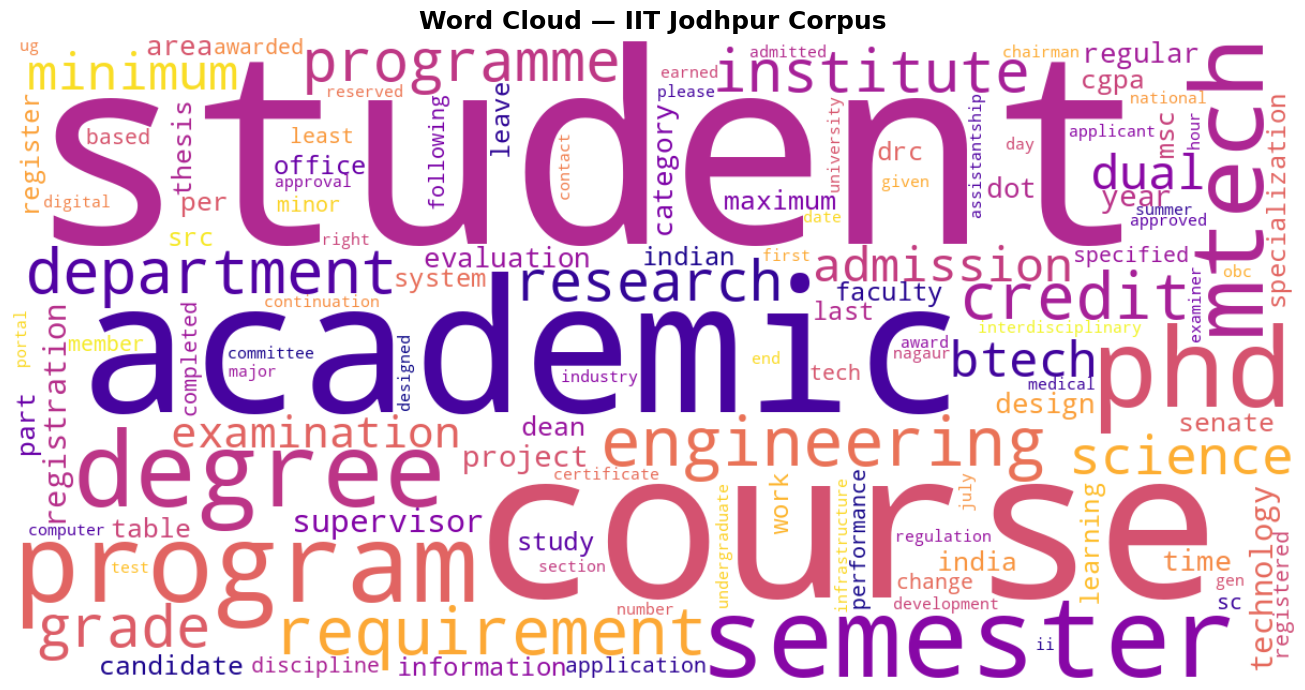

Saved: wordcloud.png


In [6]:
freq = {w: c for w, c in vocab_counter.items() if c >= MIN_COUNT}

wc = WordCloud(width=1200, height=600, background_color="white",
               colormap="plasma", max_words=120).generate_from_frequencies(freq)

plt.figure(figsize=(15, 7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud — IIT Jodhpur Corpus", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig("wordcloud.png", dpi=150)
plt.show()
print("Saved: wordcloud.png")

Negative Sampling Distribution

In [7]:
# Unigram distribution raised to power 0.75 (as in original Word2Vec paper)
counts      = np.array([vocab_counter.get(idx2word[i], 0) ** 0.75
                        for i in range(VOCAB_SIZE)], dtype=np.float64)
noise_dist  = counts / counts.sum()

# Precompute a large table for fast sampling (alias-style approximation)
NOISE_TABLE_SIZE = 100_000
noise_table = np.random.choice(VOCAB_SIZE, size=NOISE_TABLE_SIZE,
                                p=noise_dist).tolist()
_noise_ptr  = [0]

def get_negative_samples(target_idx, k):
    """Return k negative sample indices != target using precomputed table."""
    samples = []
    ptr     = _noise_ptr[0]
    while len(samples) < k:
        idx = noise_table[ptr % NOISE_TABLE_SIZE]
        ptr += 1
        if idx != target_idx:
            samples.append(idx)
    _noise_ptr[0] = ptr % NOISE_TABLE_SIZE
    return samples

print(f"Noise table built. VOCAB_SIZE={VOCAB_SIZE}")

Noise table built. VOCAB_SIZE=1315


Build Training Pairs

In [8]:
def build_cbow_pairs(corpus, word2idx, window):
    """
    Returns list of (context_indices[], target_idx).
    CBOW: predict center word from context.
    """
    pairs = []
    for sentence in corpus:
        ids = [word2idx[w] for w in sentence if w in word2idx]
        for i, target in enumerate(ids):
            ctx = []
            for j in range(max(0, i - window), min(len(ids), i + window + 1)):
                if j != i:
                    ctx.append(ids[j])
            if ctx:
                pairs.append((ctx, target))
    return pairs

def build_skipgram_pairs(corpus, word2idx, window):
    """
    Returns list of (center_idx, context_idx).
    Skip-gram: predict context word from center.
    """
    pairs = []
    for sentence in corpus:
        ids = [word2idx[w] for w in sentence if w in word2idx]
        for i, center in enumerate(ids):
            for j in range(max(0, i - window), min(len(ids), i + window + 1)):
                if j != i:
                    pairs.append((center, ids[j]))
    return pairs

print("Pair builder functions defined.")

Pair builder functions defined.


In [9]:
# ── All the math Word2Vec needs, written by hand ──────────────────────────

def sigmoid(x):
    """Numerically stable sigmoid."""
    return np.where(x >= 0,
                    1 / (1 + np.exp(-x)),
                    np.exp(x) / (1 + np.exp(x)))

def neg_sampling_loss_and_grads(h, pos_idx, neg_idxs, W_out):
    """
    Compute Negative Sampling loss and gradients given:
      h        : hidden / input vector  (D,)
      pos_idx  : positive output word index
      neg_idxs : list of k negative word indices
      W_out    : output embedding matrix (V x D)

    Returns:
      loss        : scalar float
      dh          : gradient w.r.t. h        (D,)
      dpos        : gradient w.r.t. W_out[pos_idx]   (D,)
      dneg        : gradient w.r.t. W_out[neg_idxs]  (k x D)
    """
    # Positive sample
    v_pos    = W_out[pos_idx]                    # (D,)
    score_p  = sigmoid(np.dot(h, v_pos))         # scalar
    loss_p   = -np.log(score_p + 1e-10)

    # Negative samples
    v_neg    = W_out[neg_idxs]                   # (k, D)
    scores_n = sigmoid(-v_neg @ h)               # (k,)   sigmoid(-u·h)
    loss_n   = -np.sum(np.log(scores_n + 1e-10))

    loss = loss_p + loss_n

    # Gradients  (from d/dh of the loss)
    # dL/dh from positive:  (σ(u_pos·h) - 1) * u_pos
    dh_pos  = (score_p - 1.0) * v_pos            # (D,)

    # dL/dh from negatives: sum_k (1 - σ(-u_neg·h)) * (-u_neg)
    #                      = sum_k (σ(u_neg·h)) * u_neg
    coeff_n = (1.0 - scores_n)                   # (k,)
    dh_neg  = coeff_n @ v_neg                    # (D,)

    dh   = dh_pos + dh_neg                       # (D,)

    # Gradient w.r.t output vectors
    dpos = (score_p - 1.0) * h                   # (D,)
    dneg = np.outer(1.0 - scores_n, h)           # (k, D)  → (1-σ(-u·h))*(-h) simplified

    return loss, dh, dpos, dneg

print("NumPy math primitives defined.")

NumPy math primitives defined.


CBOW Trainer

In [10]:
def train_cbow_numpy(corpus, word2idx, idx2word, vocab_size,
                     embed_dim, window, num_neg, epochs, lr):
    V, D = vocab_size, embed_dim

    W_in  = np.random.uniform(-0.5/D, 0.5/D, (V, D))
    W_out = np.zeros((V, D))

    pairs = build_cbow_pairs(corpus, word2idx, window)
    N     = len(pairs)
    print(f"  CBOW training pairs: {N:,}")

    epoch_losses = []   # ← ADD THIS LINE

    for epoch in range(1, epochs + 1):
        total_loss = 0.0
        random.shuffle(pairs)
        t0 = time.time()

        for ctx_ids, target_idx in pairs:
            ctx_vecs = W_in[ctx_ids]
            h        = ctx_vecs.mean(axis=0)

            neg_idxs = get_negative_samples(target_idx, num_neg)

            loss, dh, dpos, dneg = neg_sampling_loss_and_grads(
                h, target_idx, neg_idxs, W_out)
            total_loss += loss

            W_out[target_idx] -= lr * dpos
            for ni, grad in zip(neg_idxs, dneg):
                W_out[ni]     -= lr * grad

            dW_in = dh / len(ctx_ids)
            for ci in ctx_ids:
                W_in[ci]      -= lr * dW_in

        avg_loss = total_loss / N
        epoch_losses.append(avg_loss)   # ← ADD THIS LINE
        print(f"  [CBOW] Epoch {epoch}/{epochs} | "
              f"Avg Loss: {avg_loss:.5f} | Time: {time.time()-t0:.1f}s")

    return W_in, W_out, epoch_losses

print("CBOW trainer defined.")

CBOW trainer defined.


Skip-Gram Trainer

In [11]:
def train_skipgram_numpy(corpus, word2idx, idx2word, vocab_size,
                         embed_dim, window, num_neg, epochs, lr):
    V, D = vocab_size, embed_dim

    W_in  = np.random.uniform(-0.5/D, 0.5/D, (V, D))
    W_out = np.zeros((V, D))

    pairs = build_skipgram_pairs(corpus, word2idx, window)
    N     = len(pairs)
    print(f"  Skip-gram training pairs: {N:,}")

    epoch_losses = []   # ← ADD THIS LINE

    for epoch in range(1, epochs + 1):
        total_loss = 0.0
        random.shuffle(pairs)
        t0 = time.time()

        for center_idx, context_idx in pairs:
            h = W_in[center_idx]

            neg_idxs = get_negative_samples(context_idx, num_neg)

            loss, dh, dpos, dneg = neg_sampling_loss_and_grads(
                h, context_idx, neg_idxs, W_out)
            total_loss += loss

            W_out[context_idx] -= lr * dpos
            for ni, grad in zip(neg_idxs, dneg):
                W_out[ni]      -= lr * grad

            W_in[center_idx]   -= lr * dh

        avg_loss = total_loss / N
        epoch_losses.append(avg_loss)   # ← ADD THIS LINE
        print(f"  [Skip-gram] Epoch {epoch}/{epochs} | "
              f"Avg Loss: {avg_loss:.5f} | Time: {time.time()-t0:.1f}s")

    return W_in, W_out, epoch_losses

print("Skip-gram trainer defined.")

Skip-gram trainer defined.


In [12]:
# All combinations of hyperparameters
EMBED_DIMS   = [100, 200]
WINDOWS      = [3, 5]
NEG_SAMPLES  = [5, 10]

# This gives 2×2×2 = 8 combinations per architecture = 16 models total
CONFIGS = [
    {"embed_dim": d, "window": w, "num_neg": k, "epochs": 10, "lr": 0.025}
    for d in EMBED_DIMS
    for w in WINDOWS
    for k in NEG_SAMPLES
]

print(f"Total configurations : {len(CONFIGS)}")
print(f"Total models to train: {len(CONFIGS) * 2} (CBOW + Skip-gram each)\n")
print(f"{'#':<4} {'embed_dim':<12} {'window':<10} {'neg_samples'}")
print("-" * 40)
for i, cfg in enumerate(CONFIGS, 1):
    print(f"{i:<4} {cfg['embed_dim']:<12} {cfg['window']:<10} {cfg['num_neg']}")

Total configurations : 8
Total models to train: 16 (CBOW + Skip-gram each)

#    embed_dim    window     neg_samples
----------------------------------------
1    100          3          5
2    100          3          10
3    100          5          5
4    100          5          10
5    200          3          5
6    200          3          10
7    200          5          5
8    200          5          10


In [13]:
trained      = {}   # key: "CBOW_dim100_win5_neg5"  → W_in numpy array
loss_log     = {}   # key: same                      → list of per-epoch avg losses
results_rows = []   # for summary table

for cfg in CONFIGS:
    D, W, K = cfg["embed_dim"], cfg["window"], cfg["num_neg"]
    tag = f"dim{D}_win{W}_neg{K}"

    print(f"\n{'='*60}")
    print(f"CONFIG → embed_dim={D}  window={W}  neg_samples={K}")
    print(f"{'='*60}")

    # ── CBOW ────────────────────────────────────────────────────
    print("\n[CBOW]")
    cbow_W_in, _, cbow_losses = train_cbow_numpy(
        tokenized_corpus, word2idx, idx2word, VOCAB_SIZE,
        D, W, K, cfg["epochs"], cfg["lr"])

    cbow_key = f"CBOW_{tag}"
    trained[cbow_key]  = cbow_W_in
    loss_log[cbow_key] = cbow_losses
    results_rows.append({
        "Model":        cbow_key,
        "Architecture": "CBOW",
        "Embed Dim":    D,
        "Window":       W,
        "Neg Samples":  K,
        "Final Loss":   round(cbow_losses[-1], 5),
        "Vocab Size":   VOCAB_SIZE,
    })

    # ── Skip-gram ────────────────────────────────────────────────
    print("\n[Skip-gram]")
    sg_W_in, _, sg_losses = train_skipgram_numpy(
        tokenized_corpus, word2idx, idx2word, VOCAB_SIZE,
        D, W, K, cfg["epochs"], cfg["lr"])

    sg_key = f"SkipGram_{tag}"
    trained[sg_key]  = sg_W_in
    loss_log[sg_key] = sg_losses
    results_rows.append({
        "Model":        sg_key,
        "Architecture": "Skip-gram",
        "Embed Dim":    D,
        "Window":       W,
        "Neg Samples":  K,
        "Final Loss":   round(sg_losses[-1], 5),
        "Vocab Size":   VOCAB_SIZE,
    })

print("\n\n✅ All models trained!")


CONFIG → embed_dim=100  window=3  neg_samples=5

[CBOW]
  CBOW training pairs: 11,901
  [CBOW] Epoch 1/10 | Avg Loss: 4.15888 | Time: 1.2s
  [CBOW] Epoch 2/10 | Avg Loss: 4.15874 | Time: 1.2s
  [CBOW] Epoch 3/10 | Avg Loss: 4.15601 | Time: 1.9s
  [CBOW] Epoch 4/10 | Avg Loss: 4.11093 | Time: 1.7s
  [CBOW] Epoch 5/10 | Avg Loss: 3.82022 | Time: 1.2s
  [CBOW] Epoch 6/10 | Avg Loss: 3.36888 | Time: 1.4s
  [CBOW] Epoch 7/10 | Avg Loss: 3.08298 | Time: 1.5s
  [CBOW] Epoch 8/10 | Avg Loss: 2.94171 | Time: 1.2s
  [CBOW] Epoch 9/10 | Avg Loss: 2.86211 | Time: 1.2s
  [CBOW] Epoch 10/10 | Avg Loss: 2.80950 | Time: 1.2s

[Skip-gram]
  Skip-gram training pairs: 71,166
  [Skip-gram] Epoch 1/10 | Avg Loss: 4.03568 | Time: 4.6s
  [Skip-gram] Epoch 2/10 | Avg Loss: 3.01270 | Time: 5.2s
  [Skip-gram] Epoch 3/10 | Avg Loss: 2.58987 | Time: 4.7s
  [Skip-gram] Epoch 4/10 | Avg Loss: 2.38384 | Time: 5.2s
  [Skip-gram] Epoch 5/10 | Avg Loss: 2.25130 | Time: 4.6s
  [Skip-gram] Epoch 6/10 | Avg Loss: 2.14641

In [14]:
df_results = pd.DataFrame(results_rows)

# Sort by architecture then final loss
df_results = df_results.sort_values(["Architecture", "Final Loss"]).reset_index(drop=True)

print("=" * 75)
print("TRAINING RESULTS — ALL CONFIGURATIONS")
print("=" * 75)
print(df_results.to_string(index=False))

# Best model per architecture
best_cbow_row = df_results[df_results["Architecture"] == "CBOW"].iloc[0]
best_sg_row   = df_results[df_results["Architecture"] == "Skip-gram"].iloc[0]

print(f"\nBest CBOW      → {best_cbow_row['Model']}  (loss={best_cbow_row['Final Loss']})")
print(f"Best Skip-gram → {best_sg_row['Model']}  (loss={best_sg_row['Final Loss']})")

# Save table to CSV for report
df_results.to_csv("model_results.csv", index=False)
print("\nSaved: model_results.csv")

TRAINING RESULTS — ALL CONFIGURATIONS
                     Model Architecture  Embed Dim  Window  Neg Samples  Final Loss  Vocab Size
     CBOW_dim100_win5_neg5         CBOW        100       5            5     2.79088        1315
     CBOW_dim200_win5_neg5         CBOW        200       5            5     2.80418        1315
     CBOW_dim100_win3_neg5         CBOW        100       3            5     2.80950        1315
     CBOW_dim200_win3_neg5         CBOW        200       3            5     2.82299        1315
    CBOW_dim100_win3_neg10         CBOW        100       3           10     3.31696        1315
    CBOW_dim100_win5_neg10         CBOW        100       5           10     3.34293        1315
    CBOW_dim200_win3_neg10         CBOW        200       3           10     3.34852        1315
    CBOW_dim200_win5_neg10         CBOW        200       5           10     3.37972        1315
 SkipGram_dim100_win5_neg5    Skip-gram        100       5            5     1.75069        1315
 S

In [15]:
# Pick best models based on lowest final loss from the results table
best_cbow_key = best_cbow_row["Model"]
best_sg_key   = best_sg_row["Model"]

W_cbow = trained[best_cbow_key]
W_sg   = trained[best_sg_key]

print(f"Using for analysis:")
print(f"  CBOW      → {best_cbow_key}")
print(f"  Skip-gram → {best_sg_key}")

Using for analysis:
  CBOW      → CBOW_dim100_win5_neg5
  Skip-gram → SkipGram_dim100_win5_neg5


Cosine Similarity and Analogy Utils

In [16]:
def cosine_similarity(v1, v2):
    denom = (np.linalg.norm(v1) * np.linalg.norm(v2)) + 1e-10
    return float(np.dot(v1, v2) / denom)

def most_similar(W, word, topn=5):
    """Top-n nearest neighbors by cosine similarity."""
    if word not in word2idx:
        return []
    idx = word2idx[word]
    vec = W[idx]
    # Vectorised cosine over entire matrix
    norms = np.linalg.norm(W, axis=1) + 1e-10     # (V,)
    sims  = W @ vec / (norms * np.linalg.norm(vec))
    sims[idx] = -1                                 # exclude self
    top_ids = np.argsort(-sims)[:topn]
    return [(idx2word[i], float(sims[i])) for i in top_ids]

def analogy(W, word_a, word_b, word_c, topn=5):
    """Solve: word_a : word_b :: word_c : ?  via  vec(b) - vec(a) + vec(c)"""
    for w in [word_a, word_b, word_c]:
        if w not in word2idx:
            print(f"  '{w}' not in vocab.")
            return []
    query   = W[word2idx[word_b]] - W[word2idx[word_a]] + W[word2idx[word_c]]
    exclude = {word2idx[w] for w in [word_a, word_b, word_c]}
    norms   = np.linalg.norm(W, axis=1) + 1e-10
    sims    = W @ query / (norms * np.linalg.norm(query))
    for i in exclude:
        sims[i] = -1
    top_ids = np.argsort(-sims)[:topn]
    return [(idx2word[i], float(sims[i])) for i in top_ids]

print("Similarity utilities defined.")

Similarity utilities defined.


Nearest Neighbors

In [17]:
# Use first config embeddings
tag      = "dim100_win5_neg5"
W_cbow   = trained[f"CBOW_{tag}"]
W_sg     = trained[f"SkipGram_{tag}"]

query_words = ["research", "student", "phd", "exam"]

print("=" * 72)
print(f"{'Word':<14}{'Rank':<6}{'CBOW Neighbor':<32}{'Skip-gram Neighbor'}")
print("=" * 72)

for word in query_words:
    c_nn = most_similar(W_cbow, word, topn=5)
    s_nn = most_similar(W_sg,   word, topn=5)
    for i in range(5):
        c = f"{c_nn[i][0]} ({c_nn[i][1]:.3f})" if i < len(c_nn) else "N/A"
        s = f"{s_nn[i][0]} ({s_nn[i][1]:.3f})" if i < len(s_nn) else "N/A"
        label = word if i == 0 else ""
        print(f"{label:<14}{i+1:<6}{c:<32}{s}")
    print("-" * 72)

Word          Rank  CBOW Neighbor                   Skip-gram Neighbor
research      1     application (1.000)             conversant (0.607)
              2     development (1.000)             proposal (0.597)
              3     design (1.000)                  patent (0.597)
              4     industry (1.000)                guidance (0.581)
              5     national (1.000)                teaching (0.565)
------------------------------------------------------------------------
student       1     academic (1.000)                allowed (0.625)
              2     semester (1.000)                issued (0.600)
              3     registration (1.000)            provided (0.586)
              4     per (1.000)                     alone (0.583)
              5     approved (0.999)                admitted (0.580)
------------------------------------------------------------------------
phd           1     degree (0.999)                  relaxation (0.615)
              2     tech (0.

In [18]:
analogy_tests = [
    ("ug",         "btech",       "pg"),
    ("professor",  "research",    "student"),
    ("department", "engineering", "school"),
]

print("ANALOGY EXPERIMENTS")
print("=" * 60)
for a, b, c in analogy_tests:
    print(f"\n  {a.upper()} : {b.upper()} :: {c.upper()} : ?")
    for name, W in [("CBOW", W_cbow), ("Skip-gram", W_sg)]:
        res = analogy(W, a, b, c, topn=3)
        if res:
            out = ", ".join([f"{w}({s:.3f})" for w, s in res])
            print(f"    [{name}] -> {out}")
        else:
            print(f"    [{name}] -> word missing from vocab")

ANALOGY EXPERIMENTS

  UG : BTECH :: PG : ?
    [CBOW] -> discipline(0.998), science(0.998), engineering(0.998)
    [Skip-gram] -> bouquet(0.741), newer(0.728), c(0.720)

  PROFESSOR : RESEARCH :: STUDENT : ?
    [CBOW] -> semester(1.000), per(1.000), leave(1.000)
    [Skip-gram] -> eligible(0.495), satisfied(0.490), proposal(0.481)

  DEPARTMENT : ENGINEERING :: SCHOOL : ?
    [CBOW] -> electrical(0.941), civil(0.937), metallurgical(0.933)
    [Skip-gram] -> liberal(0.717), sustainability(0.715), obliterating(0.708)


PCA and t-SNE Visualization

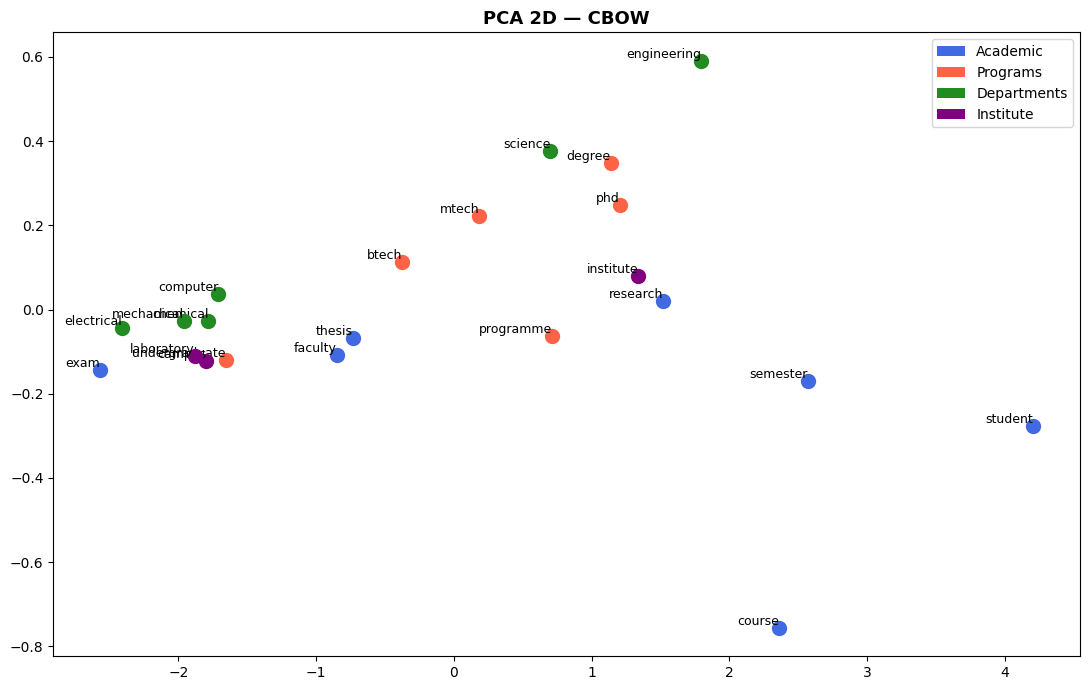

Saved: pca_CBOW.png


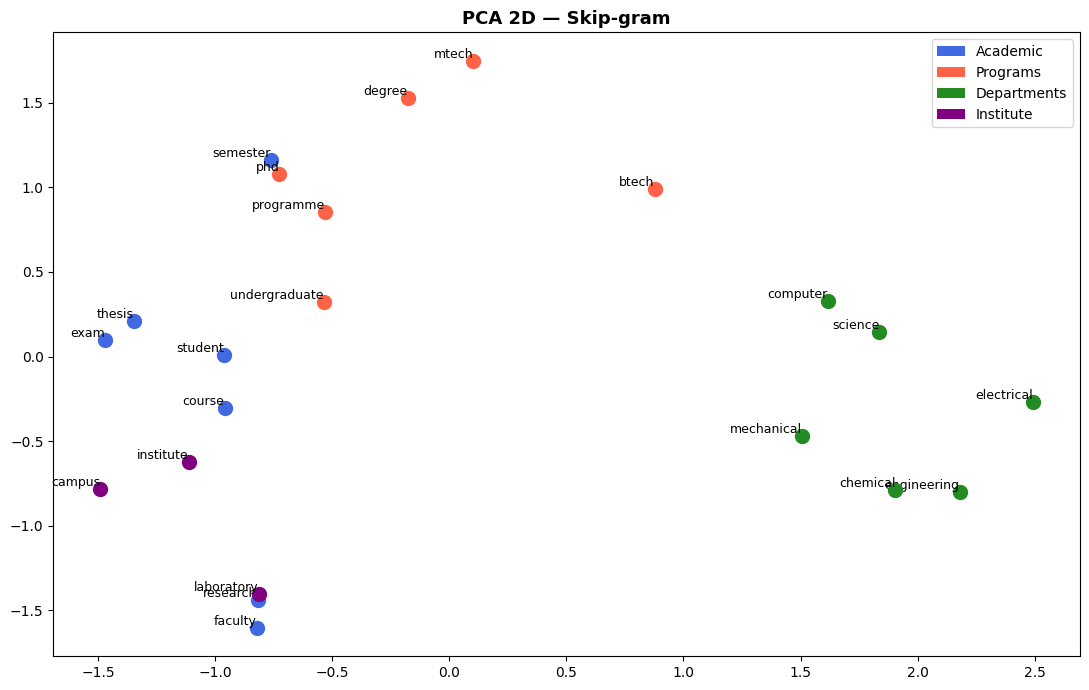

Saved: pca_Skip-gram.png


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


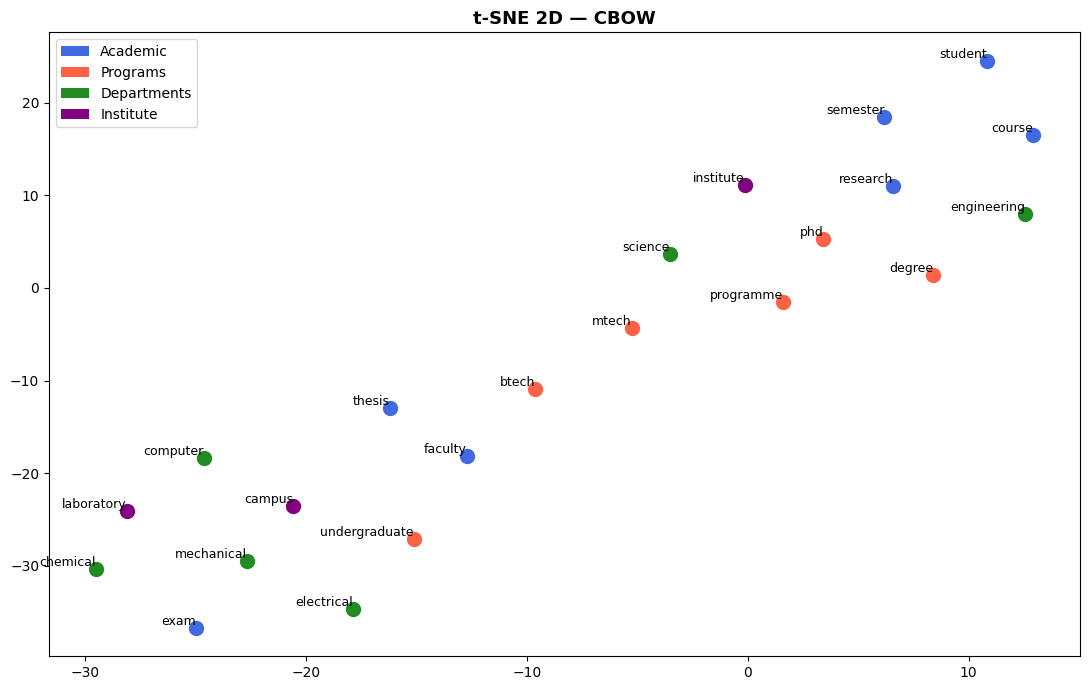

Saved: tsne_CBOW.png


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


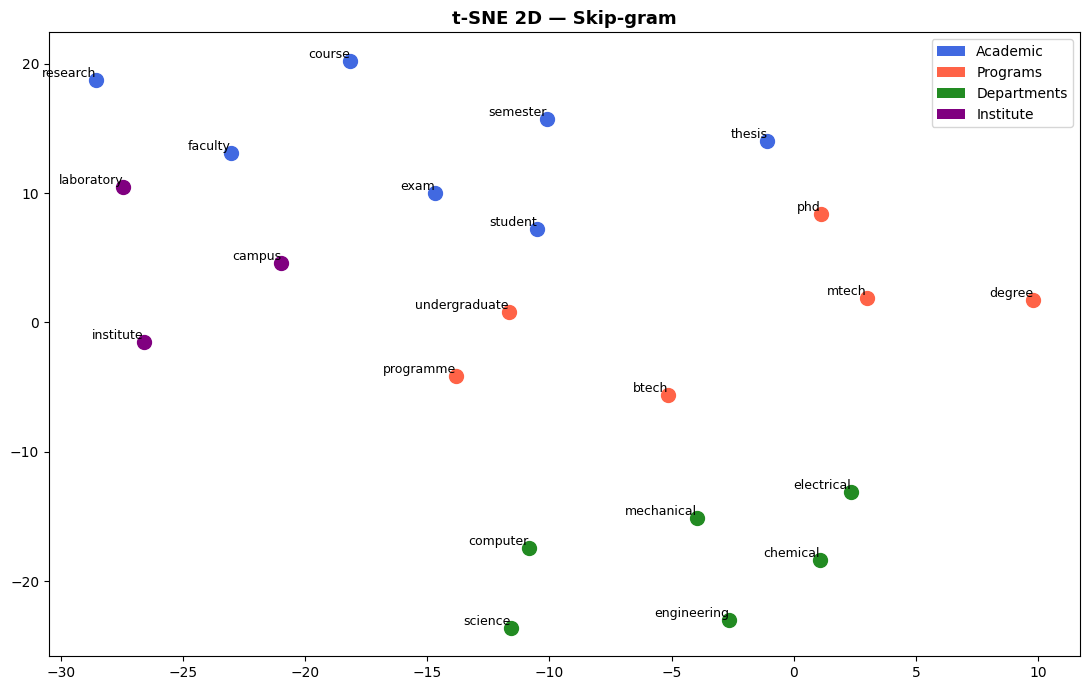

Saved: tsne_Skip-gram.png


In [19]:
word_groups = {
    "Academic":    ["research","student","faculty","course","exam","thesis","semester"],
    "Programs":    ["btech","mtech","phd","undergraduate","degree","programme"],
    "Departments": ["engineering","chemical","mechanical","electrical","computer","science"],
    "Institute":   ["iitj","jodhpur","institute","campus","laboratory"],
}
group_colors = {
    "Academic":    "royalblue",
    "Programs":    "tomato",
    "Departments": "forestgreen",
    "Institute":   "purple",
}

def plot_2d(W, model_name, method="pca"):
    words, colors = [], []
    for grp, wlist in word_groups.items():
        for w in wlist:
            if w in word2idx:
                words.append(w)
                colors.append(group_colors[grp])

    if len(words) < 4:
        print(f"Too few vocab words for {model_name}")
        return

    vecs = np.array([W[word2idx[w]] for w in words])

    if method == "pca":
        coords = PCA(n_components=2, random_state=42).fit_transform(vecs)
        title  = f"PCA 2D — {model_name}"
    else:
        perp   = min(10, len(words) - 1)
        coords = TSNE(n_components=2, perplexity=perp,
                      random_state=42, n_iter=1000).fit_transform(vecs)
        title  = f"t-SNE 2D — {model_name}"

    plt.figure(figsize=(11, 7))
    for i, (w, c) in enumerate(zip(words, colors)):
        plt.scatter(coords[i, 0], coords[i, 1], color=c, s=100, zorder=3)
        plt.annotate(w, (coords[i, 0], coords[i, 1]),
                     fontsize=9, ha='right', va='bottom')

    from matplotlib.patches import Patch
    legend = [Patch(facecolor=group_colors[g], label=g) for g in word_groups]
    plt.legend(handles=legend, loc="best")
    plt.title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    fname = f"{method}_{model_name.replace(' ','_')}.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"Saved: {fname}")

plot_2d(W_cbow, "CBOW",      "pca")
plot_2d(W_sg,   "Skip-gram", "pca")
plot_2d(W_cbow, "CBOW",      "tsne")
plot_2d(W_sg,   "Skip-gram", "tsne")

Final Summary

In [20]:
print("=" * 55)
print("FINAL SUMMARY")
print("=" * 55)
print(f"  Documents scraped : {len(tokenized_corpus)}")
print(f"  Total tokens      : {len(all_tokens):,}")
print(f"  Vocabulary size   : {VOCAB_SIZE:,}")

rows = []
for name in trained:
    arch  = "CBOW" if "CBOW" in name else "Skip-gram"
    parts = name.split("_")
    rows.append({
        "Model":        name,
        "Architecture": arch,
        "Embed Dim":    parts[1].replace("dim",""),
        "Window":       parts[2].replace("win",""),
        "Neg Samples":  parts[3].replace("neg",""),
        "Vocab Size":   VOCAB_SIZE,
    })

print()
print(pd.DataFrame(rows).to_string(index=False))

print("\nOutput files:")
for f in ["cleaned_corpus.txt","wordcloud.png",
          "pca_CBOW.png","pca_Skip-gram.png",
          "tsne_CBOW.png","tsne_Skip-gram.png"]:
    print(f"  {f}")

FINAL SUMMARY
  Documents scraped : 20
  Total tokens      : 12,893
  Vocabulary size   : 1,315

                     Model Architecture Embed Dim Window Neg Samples  Vocab Size
     CBOW_dim100_win3_neg5         CBOW       100      3           5        1315
 SkipGram_dim100_win3_neg5    Skip-gram       100      3           5        1315
    CBOW_dim100_win3_neg10         CBOW       100      3          10        1315
SkipGram_dim100_win3_neg10    Skip-gram       100      3          10        1315
     CBOW_dim100_win5_neg5         CBOW       100      5           5        1315
 SkipGram_dim100_win5_neg5    Skip-gram       100      5           5        1315
    CBOW_dim100_win5_neg10         CBOW       100      5          10        1315
SkipGram_dim100_win5_neg10    Skip-gram       100      5          10        1315
     CBOW_dim200_win3_neg5         CBOW       200      3           5        1315
 SkipGram_dim200_win3_neg5    Skip-gram       200      3           5        1315
    CBOW_dim